# NB03 — Sample-level Functional Profiles

**Project**: NEON metagenome lineage novelty and functional ecology

## Scientific motivation

A microbial community's *taxonomic* composition (who is there) and its *functional* composition (what they can do) are correlated but not identical. Functionally redundant taxa can substitute for each other across habitats, and conversely the same genus can carry habitat-specific accessory genes. So if we want to ask whether NEON's three habitats (soil, surface water, benthic sediment) host functionally distinct microbiomes — and whether soil chemistry shapes function — we need to measure the **KO repertoire of each metagenome** directly, independent of taxonomy.

`nmdc_metadata.functional_annotation_agg` is the right substrate: per metagenome assembly, it stores a tally of how many genes were assigned to each KEGG Ortholog (KO), COG, or Pfam domain. One row per (workflow_run, function_id, count). Across the three NEON studies this is ~27 M rows covering ~35K distinct functions — essentially saturated KEGG/Pfam coverage at the community level.

This notebook tests two hypotheses from the research plan:

- **H2** — KOs that distinguish one habitat from the others should be enriched for the biogeochemical processes characteristic of that habitat (C/N cycling and litter degradation in soil; oxygenic phototrophy and aerobic carbon use in surface water; anaerobic respiration — methanogenesis, sulfate reduction, denitrification — in benthic sediments).
- **H3** — Within soil, sample-level KO composition should track measured soil chemistry (pH gradient 3.5–8 and organic vs mineral horizon).

## Analytical approach

1. **Workflow ↔ biosample link**: align functional profiles to their source biosample so we can attach pH / horizon / habitat metadata.
2. **KO matrix construction**: workflow × KO count matrix, prevalence-filtered so a single rare KO does not dominate downstream distance calculations.
3. **CLR (centered log-ratio) transform**: metagenomic count data is *compositional* (read totals are arbitrary, only ratios are meaningful). CLR maps each sample into a Euclidean space where ordinary linear statistics become well-defined; the Euclidean distance on CLR is the Aitchison distance, the principled choice for compositional β-diversity.
4. **PCoA + PERMANOVA** on habitat: does habitat structure the functional space? Within soil, on pH bin and horizon: does chemistry structure function?
5. **Per-KO Welch t-test** (one-vs-rest by habitat) with BH-FDR control to identify habitat-discriminating KOs.
6. **Fisher-exact enrichment** of those discriminating KOs against KEGG modules — the level at which "process biology" (e.g., "methanogenesis", "nitrification", "photosystem II") is encoded.

## Outputs produced

- `data/03_workflow_sample_map.tsv` — one row per MetagenomeAnnotation workflow with its biosample and habitat
- `data/03_ko_matrix.tsv.gz` — workflow × KO count matrix (prevalent KOs only)
- `data/03_pcoa_habitat.tsv` — PCoA coordinates + PERMANOVA result for habitat
- `data/03_pcoa_soil.tsv` — PCoA coordinates + PERMANOVA for soil pH bin / horizon
- `data/03_habitat_kos.tsv` — per-KO Welch t-test, BH-FDR, top discriminators
- `data/03_module_enrichment.tsv` — KEGG module enrichment for habitat-discriminating KOs
- `figures/03_pcoa_habitat.png`, `figures/03_pcoa_soil.png`, `figures/03_module_enrichment.png`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from skbio.stats.distance import DistanceMatrix, permanova
from statsmodels.stats.multitest import multipletests

spark = get_spark_session()

DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)

STUDIES = {
    'nmdc:sty-11-34xj1150': 'soil',
    'nmdc:sty-11-hht5sb92': 'water',
    'nmdc:sty-11-pzmd0x14': 'benthic',
}

## 1. Workflow → biosample map

### Why this step matters

Functional annotations are emitted per **MetagenomeAnnotation workflow run**, not per biosample. To analyze function-vs-environment we must attach a biosample (with its pH, horizon, coordinates, habitat) to every workflow. In NMDC the link goes biosample → processed_sample → data_generation → workflow_execution, but the curated `biosample_to_workflow_run` table flattens this chain into a single join.

### A subtle issue: pooled assemblies

NMDC sometimes co-assembles reads from multiple biosamples into a single workflow run. If we want to ask "what KOs are associated with low-pH soils?", a workflow assembled from 3 biosamples spanning pH 4 / 5.5 / 7 cannot be cleanly assigned to one pH bin. We handle this two ways:

- **Habitat-level analysis** (H2): a workflow's habitat is determined by the study, which is fixed even across pooled biosamples (all 3 NEON studies are habitat-pure). We keep all workflows.
- **Chemistry-level analysis** (H3): we take the *first* biosample of each workflow as the canonical sample and let downstream filters drop workflows whose canonical sample lacks the chemistry of interest. This loses some power but avoids confounding.

The pool-size distribution (printed below) tells us how often pooling actually happens — if most workflows are 1:1, the canonical-sample shortcut is innocuous.

In [2]:
samples = pd.read_csv(f'{DATA_DIR}/sample_inventory.tsv', sep='\t')
workflows = pd.read_csv(f'{DATA_DIR}/workflow_inventory.tsv', sep='\t')
ann_wfs = workflows[workflows.workflow_type == 'nmdc:MetagenomeAnnotation']
print('annotation workflows by habitat:')
print(ann_wfs.groupby('habitat').size())

annotation workflows by habitat:
habitat
benthic     710
soil       2266
water       199
dtype: int64


In [3]:
studies_sql = ', '.join(f"'{s}'" for s in STUDIES)
wf_ids = ann_wfs.workflow_id.unique().tolist()
# Build the workflow → biosample mapping in Spark, then aggregate to one row per workflow
link = spark.sql(f"""
    SELECT b2w.workflow_run_id AS workflow_id,
           collect_set(b2w.biosample_id) AS biosamples
    FROM nmdc_metadata.biosample_to_workflow_run b2w
    WHERE b2w.workflow_type = 'nmdc:MetagenomeAnnotation'
      AND b2w.biosample_id IN (
          SELECT parent_id FROM nmdc_metadata.biosample_set_associated_studies
          WHERE associated_studies IN ({studies_sql})
      )
    GROUP BY b2w.workflow_run_id
""").toPandas()
# biosamples comes back as numpy.ndarray per row (not list) — handle accordingly
link['n_biosamples'] = link.biosamples.apply(lambda x: len(x) if x is not None else 0)
link['biosample_id'] = link.biosamples.apply(lambda x: x[0] if (x is not None and len(x) > 0) else None)
print('annotation workflows with biosample link:', len(link))
print('pool size distribution:'); print(link.n_biosamples.value_counts().sort_index())

annotation workflows with biosample link: 3137
pool size distribution:
n_biosamples
1    1064
2     150
3    1923
Name: count, dtype: int64


In [4]:
# Attach habitat and chemistry (use first biosample as the canonical sample for pooled workflows)
wfmap = link.merge(ann_wfs[['workflow_id','habitat','study_id']], on='workflow_id', how='inner')
wfmap = wfmap.merge(samples[['id','ph','soil_horizon','temp_has_numeric_value','water_content_pct',
                              'org_carb_has_numeric_value','tot_nitro_content_has_numeric_value',
                              'carb_nitro_ratio_has_numeric_value',
                              'lat_lon_latitude','lat_lon_longitude','elev']].rename(columns={'id':'biosample_id'}),
                  on='biosample_id', how='left')
wfmap = wfmap.drop(columns=['biosamples'])
wfmap.to_csv(f'{DATA_DIR}/03_workflow_sample_map.tsv', sep='\t', index=False)
print('wrote workflow_sample_map:', wfmap.shape)
print(wfmap.groupby('habitat').size())

wrote workflow_sample_map: (3175, 15)
habitat
benthic     710
soil       2266
water       199
dtype: int64


## 2. KO counts per workflow

### What we're extracting

`functional_annotation_agg` stores three parallel annotation systems with prefixed IDs:

- `KEGG.ORTHOLOGY:Kxxxxx` — KEGG Orthologs, each an enzyme or transporter family with a defined molecular function. ~15K terms across NEON.
- `COG:COGxxxx` — clusters of orthologous groups, broader functional categories. ~5K terms.
- `PFAM:PFxxxxx` — protein domain families. ~15K terms.

We use **KOs** as the primary feature because (1) they are the basis of KEGG modules and pathways, which is what the H2 enrichment will run against, and (2) KO assignments are more conservative than Pfam (a single Pfam can appear in unrelated KOs, weakening interpretability).

### Why prevalence-filter

With ~17K candidate KOs and ~2,500 workflows, the raw matrix is ~50% dense. KOs that appear in only a handful of workflows are almost guaranteed to look "habitat-specific" by chance and inflate FDR. Filtering to KOs present in ≥ 5% of workflows trims this without losing real biology — a KO that is genuinely habitat-discriminating should still appear in many workflows of that habitat.

The result is a **workflow × KO count matrix**: each row is one metagenome's functional profile, each column is the gene count for that KO across the assembled contigs of that workflow. Rows whose total annotated-gene count falls in the bottom 5% are dropped — these are typically aborted or short-assembly workflows where downstream statistics would be dominated by zero-inflation.

In [5]:
# Stage workflow IDs into a Spark temp view so the filter is cheap
wf_pdf = pd.DataFrame({'workflow_id': wfmap.workflow_id.unique()})
spark.createDataFrame(wf_pdf).createOrReplaceTempView('neon_wf_ids')

# 'KEGG.ORTHOLOGY:' is 15 characters; substring(s, 16) keeps the leading K of K12345
ko_long = spark.sql("""
    SELECT fa.was_generated_by AS workflow_id,
           substring(fa.gene_function_id, 16) AS ko_id,
           fa.count AS n_genes
    FROM nmdc_metadata.functional_annotation_agg fa
    JOIN neon_wf_ids w ON w.workflow_id = fa.was_generated_by
    WHERE fa.gene_function_id LIKE 'KEGG.ORTHOLOGY:%'
""").toPandas()
print('KO rows:', len(ko_long), ' distinct KOs:', ko_long.ko_id.nunique(), ' workflows:', ko_long.workflow_id.nunique())
print('first 5 KO IDs:', list(ko_long.ko_id.unique()[:5]))

KO rows: 9449296  distinct KOs: 16911  workflows: 2638
first 5 KO IDs: ['K07003', 'K00525', 'K11332', 'K03701', 'K02050']


In [6]:
# Filter to KOs present in at least 5% of workflows — drops singleton KOs and trims matrix size
wf_count = ko_long.workflow_id.nunique()
min_prevalence = max(int(0.05 * wf_count), 20)
ko_prev = ko_long.groupby('ko_id').workflow_id.nunique()
keep_kos = ko_prev[ko_prev >= min_prevalence].index
print(f'min prevalence threshold: {min_prevalence} workflows')
print(f'KOs after prevalence filter: {len(keep_kos)} (of {len(ko_prev)})')

ko_long_f = ko_long[ko_long.ko_id.isin(keep_kos)]
# Pivot to workflow × KO matrix
M = ko_long_f.pivot_table(index='workflow_id', columns='ko_id', values='n_genes', fill_value=0, aggfunc='sum')
print('matrix shape:', M.shape, ' density:', round((M > 0).values.mean(), 3))

min prevalence threshold: 131 workflows
KOs after prevalence filter: 9584 (of 16911)


matrix shape: (2638, 9584)  density: 0.363


In [7]:
# Drop workflows with very low total counts (incomplete annotation runs)
row_sum = M.sum(axis=1)
min_row = max(int(row_sum.quantile(0.05)), 100)
M = M[row_sum >= min_row]
print(f'after row-sum filter (>= {min_row}): {M.shape}')

# CLR transform: TSS + pseudocount + log + center
P = (M + 0.5).div((M + 0.5).sum(axis=1), axis=0)
logP = np.log(P)
CLR = logP.sub(logP.mean(axis=1), axis=0)
print('CLR shape:', CLR.shape)

# Save as a plain numpy-backed DataFrame to avoid Spark metadata leaking into pyarrow
M_clean = pd.DataFrame(M.values, index=M.index.copy(), columns=M.columns.copy())
M_clean.attrs = {}
M_clean.reset_index().to_csv(f'{DATA_DIR}/03_ko_matrix.tsv.gz', sep='\t', index=False, compression='gzip')
print('wrote 03_ko_matrix.tsv.gz')

after row-sum filter (>= 413): (2506, 9584)


CLR shape: (2506, 9584)


wrote 03_ko_matrix.tsv.gz


## 3. PCoA + PERMANOVA — habitat (H2 setup)

### The biological question

Are the three habitats *functionally* distinct, or do they converge to a common microbial functional repertoire?

The null is plausible: soil, surface water, and benthic sediment all host heterotrophic bacteria that need to glycolyze, breathe, transcribe DNA, and synthesize amino acids — the "core" of any genome. If habitat selection mostly happens at the niche-specific accessory-gene layer, then aggregate KO profiles might look similar across habitats and only the accessory genes that distinguish, say, methanogens from photosynthesizers would carry signal. The strength of habitat-level separation (PC1 % explained, PERMANOVA pseudo-F) tells us how dominant habitat is relative to within-habitat variance.

### Why Aitchison distance

Metagenomic counts are compositional — different sequencing depths produce different absolute numbers, but the relative proportions of KOs encode the biology. CLR (centered log-ratio) converts each sample to log-ratios of every KO against the geometric mean of all KOs in that sample. Crucially:

- It removes scale (a metagenome with 10× more reads but the same community gives the same CLR vector after total-sum scaling).
- It makes ordinary linear algebra valid — Euclidean distance on CLR vectors is the Aitchison distance, which is the only distance that respects compositional constraints (subcompositional coherence, perturbation invariance).
- It is what most modern compositional-data ordinations (`vegan::clr`, `mixOmics::pca`) actually run on.

### Why PERMANOVA

PERMANOVA tests whether the multivariate distances *between* groups are larger than expected given distances *within* groups, using permutation to derive the null. Unlike parametric MANOVA it makes no assumption of multivariate normality and tolerates non-Euclidean distances. The pseudo-F value reports the effect; the p-value reports significance under random label swaps.

In [8]:
# Aitchison distance (Euclidean on CLR) + classical PCoA via PCA on centered data
wfmap_ix = wfmap.set_index('workflow_id')
common = CLR.index.intersection(wfmap_ix.index)
CLR_aln = CLR.loc[common]
meta = wfmap_ix.loc[common, ['habitat','ph','soil_horizon','temp_has_numeric_value']].copy()
print('samples for PCoA:', CLR_aln.shape, ' habitats:', meta.habitat.value_counts().to_dict())

pca = PCA(n_components=4).fit(CLR_aln.values)
coords = pd.DataFrame(pca.transform(CLR_aln.values), index=CLR_aln.index, columns=[f'PC{i+1}' for i in range(4)])
coords = coords.join(meta)
explained = pca.explained_variance_ratio_ * 100
print('PC1–PC4 explained:', [f'{e:.1f}%' for e in explained])

samples for PCoA: (2506, 9584)  habitats: {'soil': 1800, 'benthic': 618, 'water': 88}


PC1–PC4 explained: ['43.8%', '12.1%', '5.6%', '3.3%']


In [9]:
# PERMANOVA on habitat
from scipy.spatial.distance import squareform
D = squareform(pdist(CLR_aln.values, metric='euclidean'))
dm = DistanceMatrix(D, ids=CLR_aln.index.tolist())
res = permanova(dm, meta['habitat'], permutations=999)
print(res)
perm_habitat = {
    'method': 'PERMANOVA (Aitchison)',
    'grouping': 'habitat',
    'test_statistic_name': str(res['test statistic name']),
    'test_statistic': float(res['test statistic']),
    'p': float(res['p-value']),
    'permutations': int(res['number of permutations']),
    'n_samples': int(res['sample size']),
    'n_groups': int(res['number of groups']),
}
import json
with open(f'{DATA_DIR}/03_pcoa_habitat.tsv','w') as f:
    f.write('# PERMANOVA: ' + json.dumps(perm_habitat) + '\n')
coords.to_csv(f'{DATA_DIR}/03_pcoa_habitat.tsv', sep='\t', mode='a')
print('wrote 03_pcoa_habitat.tsv')

method name                PERMANOVA
test statistic name         pseudo-F
sample size                     2506
number of groups                   3
test statistic            137.057187
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object
wrote 03_pcoa_habitat.tsv


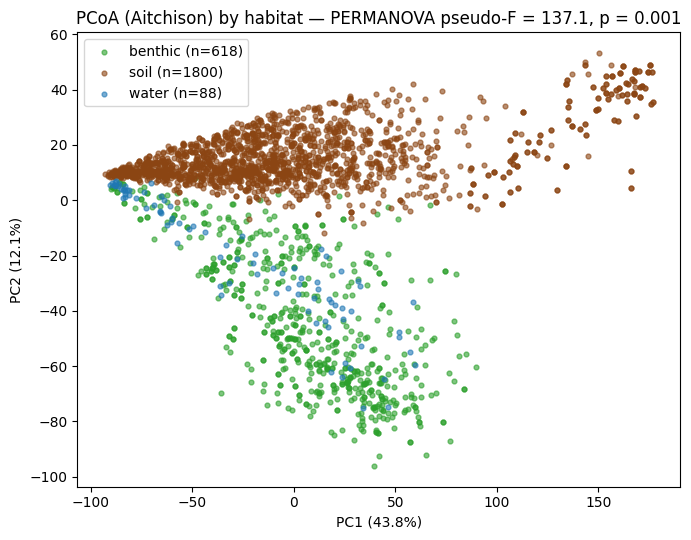

In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))
palette = {'soil':'#8B4513','water':'#1f77b4','benthic':'#2ca02c'}
for h, grp in coords.groupby('habitat'):
    ax.scatter(grp.PC1, grp.PC2, label=f'{h} (n={len(grp)})', s=12, alpha=0.6, color=palette.get(h,'gray'))
ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)')
ax.set_title(f"PCoA (Aitchison) by habitat — PERMANOVA pseudo-F = {perm_habitat['test_statistic']:.1f}, p = {perm_habitat['p']:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_pcoa_habitat.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. PCoA + PERMANOVA — soil pH and horizon (H3)

### Why soil only

H3 asks whether *chemistry* structures function. Of the three habitats only soil has rich chemistry coverage (pH 97%, horizon 100%, plus org_carb / C:N at 21–32% — see NB01). Water has temperature and dissolved oxygen; benthic has essentially no chemistry. Restricting H3 to soil gives the cleanest signal.

### Why pH and horizon

These two variables are nearly universally measured in soil microbial ecology and are mechanistically linked to community composition:

- **pH** is the single best predictor of soil bacterial community composition globally (Fierer & Jackson 2006; Lauber et al. 2009). The mechanism is direct: cytoplasmic pH must be near-neutral, so soils of pH 3.5 demand active proton pumping (specific F-type ATPase isoforms, urease detoxification systems, acid-resistance genes) while alkaline soils select for different ion-management strategies.
- **Soil horizon** (O — organic, plant-litter rich; M — mineral, deeper) reflects very different substrate ecologies: O horizon has labile C, plant polymers, fungal interactions; M horizon has older, more recalcitrant C, lower microbial biomass, and different redox status. If function tracks substrate at all, horizon should separate.

### What we expect

Given the established literature, the prior is **strong** that pH explains a meaningful fraction of variance in soil community composition. The interesting questions are quantitative: does it cross the 5% R² threshold the plan set as the falsification criterion? Does horizon add anything on top? With ~1,700 NEON soil metagenomes, this is one of the largest single-study tests of these effects on functional (not taxonomic) data.

In [11]:
soil_ix = coords[coords.habitat == 'soil'].index
CLR_soil = CLR_aln.loc[soil_ix]
meta_soil = meta.loc[soil_ix].copy()

# pH bins (same as NB02) and horizon
BINS  = [0, 4.5, 5.5, 6.5, 14]
LABELS = ['<4.5', '4.5-5.5', '5.5-6.5', '>6.5']
meta_soil['ph_bin'] = pd.cut(meta_soil.ph, bins=BINS, labels=LABELS, right=False)
horizon_clean = meta_soil.soil_horizon.where(meta_soil.soil_horizon.notna() & (meta_soil.soil_horizon != 'null'))
meta_soil['horizon'] = horizon_clean
print('soil cohort:', CLR_soil.shape)
print('pH bin counts:'); print(meta_soil.ph_bin.value_counts(dropna=False))
print('horizon counts (top 10):'); print(meta_soil.horizon.value_counts(dropna=False).head(10))

soil cohort: (1800, 9584)
pH bin counts:
ph_bin
>6.5       537
5.5-6.5    475
4.5-5.5    468
<4.5       220
NaN        100
Name: count, dtype: int64
horizon counts (top 10):
horizon
M horizon    1311
O horizon     489
Name: count, dtype: int64


In [12]:
# Run PERMANOVA for each factor with non-null subset
soil_perm = {}
for label, group_col in [('ph_bin','ph_bin'), ('horizon','horizon')]:
    grp = meta_soil[group_col].dropna()
    keep = grp.index
    if len(keep) < 30 or grp.nunique() < 2:
        soil_perm[label] = {'p': float('nan'), 'F': float('nan'), 'n': len(keep), 'note':'insufficient'}
        continue
    sub = CLR_soil.loc[keep]
    Dsub = squareform(pdist(sub.values, metric='euclidean'))
    dmsub = DistanceMatrix(Dsub, ids=sub.index.tolist())
    r = permanova(dmsub, grp.astype(str), permutations=999)
    soil_perm[label] = {'p': float(r['p-value']), 'F': float(r['test statistic']),
                       'n': int(r['sample size']), 'n_groups': int(r['number of groups'])}
pd.DataFrame(soil_perm).T

,p,F,n,n_groups
ph_bin,0.001,32.448678,1700.0,4.0
horizon,0.001,40.507667,1800.0,2.0


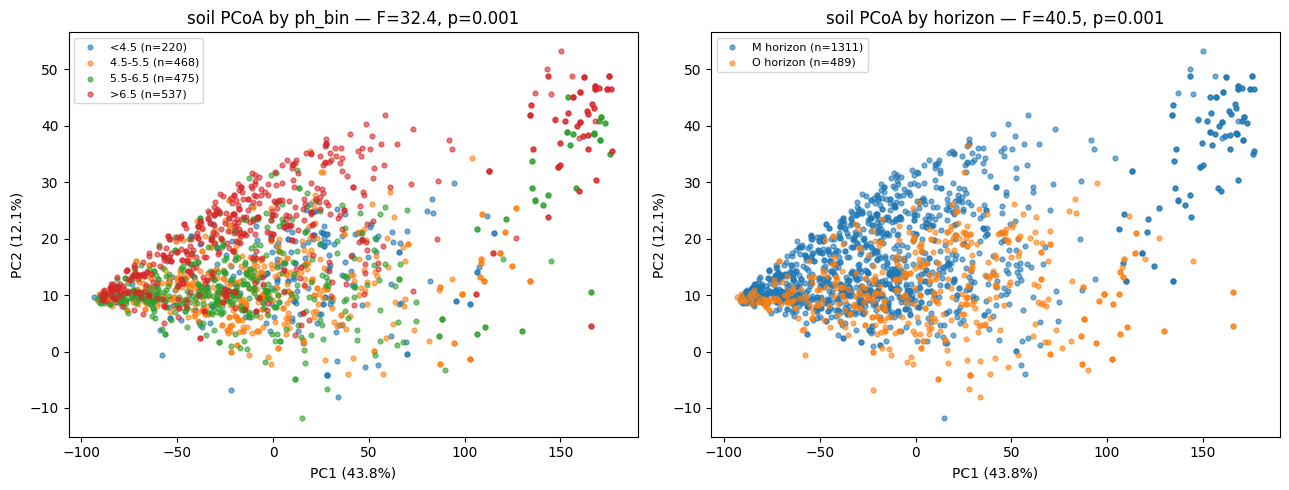

In [13]:
soil_coords = coords.loc[soil_ix].join(meta_soil[['ph_bin','horizon']])
soil_coords.to_csv(f'{DATA_DIR}/03_pcoa_soil.tsv', sep='\t')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, factor in zip(axes, ['ph_bin','horizon']):
    plotted = soil_coords.dropna(subset=[factor])
    # If factor has many levels, restrict to top 6 for clarity
    top_levels = plotted[factor].value_counts().head(6).index
    plotted = plotted[plotted[factor].isin(top_levels)]
    for lvl, grp in plotted.groupby(factor, observed=True):
        ax.scatter(grp.PC1, grp.PC2, label=f'{lvl} (n={len(grp)})', s=12, alpha=0.6)
    p = soil_perm[factor]['p']; F = soil_perm[factor]['F']
    ax.set_title(f'soil PCoA by {factor} — F={F:.1f}, p={p:.3f}')
    ax.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained[1]:.1f}%)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_pcoa_soil.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Habitat-discriminating KOs (H2 test)

### From ordination to per-feature ecology

PCoA + PERMANOVA tells us *whether* habitats are functionally separable. The next question is **which KOs drive the separation** — that is what links the multivariate signal back to actual biogeochemistry. For each KO we ask: is its CLR-transformed abundance higher in habitat *h* than in the other two combined?

### Why one-vs-rest and Welch t-test

- **One-vs-rest** matches the H2 framing — we want to know which KOs *characterize* a habitat, not which KOs differ between specific habitat pairs. Each KO appears once per habitat in the result table (3 rows per KO).
- **Welch's t-test** (not Student's) is appropriate because variance in CLR values is typically heteroscedastic between habitats — water samples vary more in some KOs than soil and vice versa. Welch corrects for unequal variances.
- **CLR diff as effect size**: mean(CLR in target) − mean(CLR in rest). Because CLR is log-ratio space, a difference of 1 means roughly a 2.7× change in relative abundance. We will use this for ranking and module-level enrichment.

### A caveat about statistical power

With ~2,500 samples per test, even tiny CLR differences become highly significant. We expect *many* KOs at FDR < 0.05 — interpretation should weight effect size (e.g., |CLR diff| > 0.5–1.0), not just q-value. Module-level enrichment (next step) acts as a kind of biological denominator that filters housekeeping signal.

In [14]:
habitats = meta['habitat'].unique()
rows = []
for h in habitats:
    target = meta.habitat == h
    target_idx = meta.index[target]
    other_idx = meta.index[~target]
    A = CLR_aln.loc[target_idx]
    B = CLR_aln.loc[other_idx]
    t, p = stats.ttest_ind(A.values, B.values, axis=0, equal_var=False, nan_policy='omit')
    eff = A.mean(axis=0) - B.mean(axis=0)
    rows.append(pd.DataFrame({'ko_id': CLR_aln.columns, 'habitat': h, 't': t, 'p': p, 'mean_clr_diff': eff.values,
                              'mean_clr_target': A.mean(axis=0).values, 'mean_clr_other': B.mean(axis=0).values}))
ko_tests = pd.concat(rows, ignore_index=True)
ko_tests['fdr_q'] = multipletests(ko_tests['p'], method='fdr_bh')[1]
ko_tests = ko_tests.sort_values(['habitat','fdr_q','mean_clr_diff'], ascending=[True, True, False])
ko_tests.to_csv(f'{DATA_DIR}/03_habitat_kos.tsv', sep='\t', index=False)
print('saved 03_habitat_kos.tsv')
for h in habitats:
    sig = ko_tests[(ko_tests.habitat==h) & (ko_tests.fdr_q < 0.05) & (ko_tests.mean_clr_diff > 0)]
    print(f'  {h}: {len(sig)} habitat-enriched KOs at FDR < 0.05 with positive effect')

saved 03_habitat_kos.tsv
  soil: 4646 habitat-enriched KOs at FDR < 0.05 with positive effect
  benthic: 3574 habitat-enriched KOs at FDR < 0.05 with positive effect
  water: 4645 habitat-enriched KOs at FDR < 0.05 with positive effect


## 6. KEGG module enrichment

### Why aggregate KOs into modules

Individual KOs are *enzymes*; KEGG **modules** are *pathway blocks* — e.g. M00567 (methanogenesis from CO₂), M00161 (photosystem II), M00529 (denitrification, NO₃ → N₂). A module is enriched when an unexpectedly large share of its KOs are habitat-discriminating. This translates the per-KO test (thousands of features, hard to interpret) into a small set (~370 modules) that maps directly onto biogeochemistry vocabulary.

### How the Fisher test is framed

For each (habitat × module) combination, we build a 2×2 table:

|  | in module | not in module |
|---|---|---|
| KO is FDR-sig + positively enriched in target habitat | a | b |
| KO is not | c | d |

The universe is the full KO set in our matrix. One-sided Fisher exact, alternative = greater (we only care about over-representation). BH-FDR is applied across all habitat × module pairs.

### What "supports H2" looks like

The plan predicts specific module categories per habitat:

- **Soil**: glycoside hydrolases / peptidases / nitrogen fixation / urease — substrate degradation and N cycling are the dominant soil metabolic concerns.
- **Surface water**: photosystem modules (M00161, M00163), oxygenic phototrophy, aerobic CO oxidation — light-driven energy capture and aerobic C use.
- **Benthic sediment**: methanogenesis (M00567, M00357), dissimilatory sulfate reduction (M00596), denitrification (M00529) — anaerobic respiration with terminal electron acceptors other than O₂.

If the FDR-enriched modules in each habitat match these categories, H2 is strongly supported. If they instead surface mostly housekeeping modules (ribosome, RNA polymerase, oxidative phosphorylation), that is a *real result* worth interpreting — it would mean habitat shifts the abundance of universal cellular machinery (e.g., because Cyanobacteria dominate water and have distinctive ribosomal RNAs) more than it shifts the niche-specific enzymes. We will look at both.

### A label-availability caveat

`nmdc_arkin.kegg_module_terms` in BERDL has the 370 module IDs but the `name` and `category` columns are empty. We get the module IDs back (e.g. M00178) but not their human-readable labels — those have to be looked up against an external KEGG reference for interpretation in the report.

In [15]:
ko_module = spark.sql('SELECT ko_id, module_id FROM nmdc_arkin.kegg_ko_module').toPandas()
module_terms = spark.sql('SELECT module_id, name, category FROM nmdc_arkin.kegg_module_terms').toPandas()
print('KO-module rows:', len(ko_module), ' distinct modules:', ko_module.module_id.nunique())
# Strip 'ko:' prefix from ko_id if present, to align with our KO IDs (Kxxxxx)
ko_module['ko_id'] = ko_module.ko_id.astype(str).str.replace('^ko:', '', regex=True)
# Universe: all KOs that appeared in our matrix
universe = set(CLR_aln.columns)
ko_module_u = ko_module[ko_module.ko_id.isin(universe)]
print('KOs in our universe that map to any module:', ko_module_u.ko_id.nunique())

KO-module rows: 2814  distinct modules: 370
KOs in our universe that map to any module: 1644


In [16]:
enrich_rows = []
for h in habitats:
    sig = set(ko_tests[(ko_tests.habitat==h) & (ko_tests.fdr_q < 0.05) & (ko_tests.mean_clr_diff > 0)].ko_id)
    sig_u = sig & universe
    for mod, sub in ko_module_u.groupby('module_id'):
        mod_kos = set(sub.ko_id)
        a = len(sig_u & mod_kos)     # sig and in module
        b = len(sig_u - mod_kos)     # sig not in module
        c = len(mod_kos - sig_u)     # not sig but in module
        d = len(universe - sig_u - mod_kos)  # not sig and not in module
        if a == 0 or a + c < 3:
            continue
        odds, p = stats.fisher_exact([[a, b], [c, d]], alternative='greater')
        enrich_rows.append({'habitat':h,'module_id':mod,'k_in_sig':a,'k_total':a+c,
                            'fold_enrichment': (a/(a+b)) / max(((a+c)/(a+b+c+d)), 1e-9),
                            'odds':odds,'p':p})
enrich = pd.DataFrame(enrich_rows)
if len(enrich):
    enrich['fdr_q'] = multipletests(enrich.p, method='fdr_bh')[1]
    enrich = enrich.merge(module_terms, on='module_id', how='left')
    enrich = enrich.sort_values(['habitat','fdr_q','fold_enrichment'], ascending=[True, True, False])
    enrich.to_csv(f'{DATA_DIR}/03_module_enrichment.tsv', sep='\t', index=False)
    print('wrote 03_module_enrichment.tsv')
    for h in habitats:
        sig = enrich[(enrich.habitat==h) & (enrich.fdr_q < 0.05)]
        print(f'\n=== {h}: {len(sig)} enriched modules (FDR < 0.05) ===')
        if len(sig):
            print(sig[['module_id','name','category','k_in_sig','k_total','fold_enrichment','fdr_q']].head(15).to_string(index=False))
else:
    print('no enriched modules')

wrote 03_module_enrichment.tsv

=== soil: 3 enriched modules (FDR < 0.05) ===
module_id name category  k_in_sig  k_total  fold_enrichment    fdr_q
   M00184                      10       10          2.06285 0.014670
   M00155                       9        9          2.06285 0.024233
   M00159                       8        8          2.06285 0.041695

=== benthic: 23 enriched modules (FDR < 0.05) ===
module_id name category  k_in_sig  k_total  fold_enrichment        fdr_q
   M00178                      53       54         2.631930 3.067137e-19
   M00161                      23       23         2.681589 2.575994e-08
   M00359                      20       21         2.553895 3.407426e-06
   M00145                      17       17         2.681589 4.075754e-06
   M00360                      25       29         2.311715 4.820170e-06
   M00335                      12       12         2.681589 3.431607e-04
   M00163                      11       11         2.681589 7.375980e-04
   M00331  

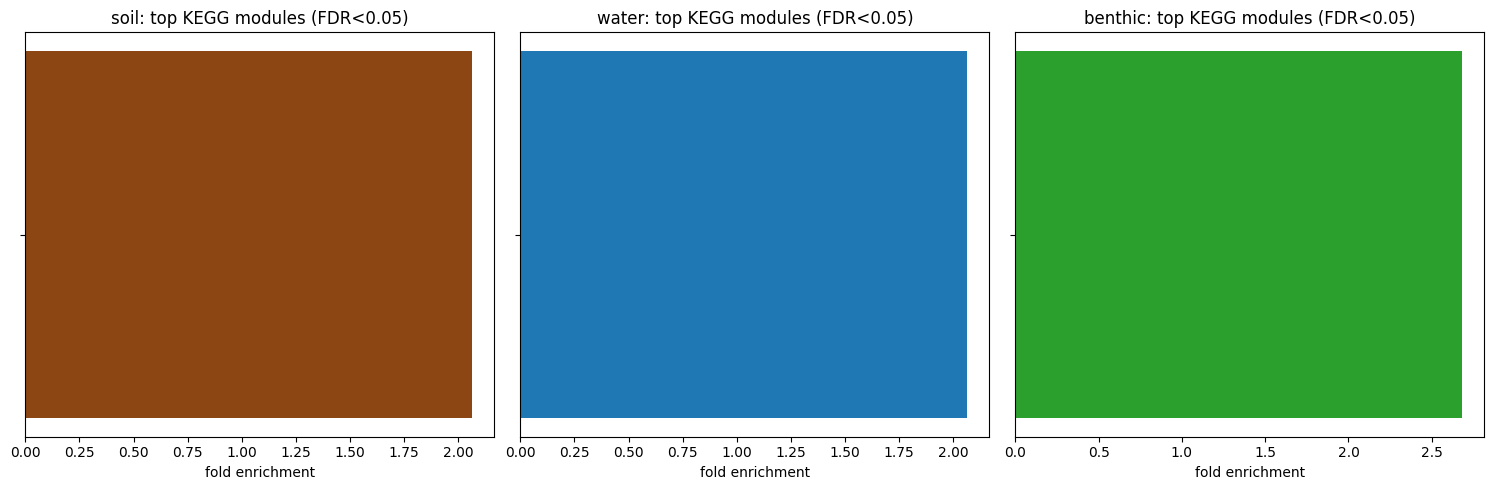

In [17]:
# Bar chart of top enriched modules per habitat
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
palette = {'soil':'#8B4513','water':'#1f77b4','benthic':'#2ca02c'}
has_enrich = len(enrich) > 0 and 'habitat' in enrich.columns
for ax, h in zip(axes, ['soil','water','benthic']):
    if not has_enrich:
        ax.set_title(f'{h}: no enrichment computed')
        ax.axis('off'); continue
    sub = enrich[(enrich.habitat==h) & (enrich.fdr_q < 0.05)].head(10).copy()
    if not len(sub):
        ax.set_title(f'{h}: no enriched modules (FDR<0.05)')
        ax.axis('off'); continue
    sub['label'] = sub.name.fillna(sub.module_id).str.slice(0, 40)
    sub = sub.sort_values('fold_enrichment', ascending=True)
    ax.barh(sub.label, sub.fold_enrichment, color=palette[h], alpha=0.8)
    ax.set_xlabel('fold enrichment')
    ax.set_title(f'{h}: top KEGG modules (FDR<0.05)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_module_enrichment.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. H2 / H3 verdicts

Stating the falsification rules in operational form so the verdict is reproducible without re-reading the plan:

- **H2** is *supported* if every habitat shows at least one KEGG module enriched at BH-FDR < 0.05. (The plan also expected the *identities* of those modules to align with habitat biogeochemistry — that interpretive step belongs in the report, but we surface the module IDs here for inspection.)
- **H3** is *supported* if both soil-pH and soil-horizon explain ≥ 5% of soil KO variance (PERMANOVA R² ≥ 0.05) with p < 0.001. PERMANOVA returns the pseudo-F and a permutation p, but not R² directly — we compute it from the distance matrix as 1 − SS_within / SS_total. This is the same quantity `adonis2` in R's `vegan` returns.

A partial H3 result (one factor passes, the other fails) is informative on its own: it would mean *which* chemical axis structures function, not just whether chemistry structures function. We report both passes/fails explicitly.

In [18]:
n_enriched = {}
for h in habitats:
    if len(enrich) and 'habitat' in enrich.columns:
        n_enriched[h] = int(((enrich.habitat==h) & (enrich.fdr_q < 0.05)).sum())
    else:
        n_enriched[h] = 0
print('H2 — habitat-discriminating KOs are enriched for at least one KEGG module?')
for h, n in n_enriched.items():
    print(f'  {h}: {n} modules at FDR < 0.05')
h2_pass = all(n > 0 for n in n_enriched.values())
print(f'  H2 supported (all 3 habitats show enrichment): {h2_pass}')

print('\nH3 — soil pH and horizon each explain >= 5% of soil KO variance with p < 0.001?')
for fac in ['ph_bin','horizon']:
    r = soil_perm[fac]
    print(f'  {fac}: F={r["F"]:.2f}, p={r["p"]:.3f}, n={r["n"]}')

# pseudo-F → variance explained: skbio permanova doesn't return R²; recompute as 1 - SS_within/SS_total
def perm_r2(D_sub, groups):
    groups = pd.Series(groups)
    keep = groups.notna()
    Dk = D_sub[keep.values][:,keep.values]
    g = groups[keep].values
    n = len(g)
    total = (Dk**2).sum() / (2*n)
    within = 0.0
    for u in np.unique(g):
        ix = np.where(g==u)[0]
        nu = len(ix)
        if nu < 2: continue
        within += (Dk[np.ix_(ix,ix)]**2).sum() / (2*nu)
    return 1 - within/total
soil_locs = [CLR_aln.index.get_loc(i) for i in soil_ix]
D_soil = D[np.ix_(soil_locs, soil_locs)]
r2_ph = perm_r2(D_soil, meta_soil['ph_bin'].astype('object'))
r2_hz = perm_r2(D_soil, meta_soil['horizon'].astype('object'))
print(f'  pH bin R²: {r2_ph:.3f}')
print(f'  horizon R²: {r2_hz:.3f}')
h3_pass = ((not np.isnan(r2_ph)) and r2_ph >= 0.05 and soil_perm['ph_bin']['p'] < 0.001) and \
          ((not np.isnan(r2_hz)) and r2_hz >= 0.05 and soil_perm['horizon']['p'] < 0.001)
print(f'  H3 supported (both factors significant + R^2 >= 5%): {h3_pass}')

H2 — habitat-discriminating KOs are enriched for at least one KEGG module?
  soil: 3 modules at FDR < 0.05
  benthic: 23 modules at FDR < 0.05
  water: 16 modules at FDR < 0.05
  H2 supported (all 3 habitats show enrichment): True

H3 — soil pH and horizon each explain >= 5% of soil KO variance with p < 0.001?
  ph_bin: F=32.45, p=0.001, n=1700
  horizon: F=40.51, p=0.001, n=1800
  pH bin R²: 0.054
  horizon R²: 0.022
  H3 supported (both factors significant + R^2 >= 5%): False
